# Remote Sensing Data & Methods 


<br>
<font size="6"> <b> Landsat 9 <b> </font>

<font size="4"> <b> DNs to Radiance Conversion<font color='rgba(200,0,0,0.2)'> </font> </b> </font>

<font size="4"> <b> Dr. M. Adnan Siddique, and Ehtasham Naseer</b> 
<font size="3">  <br>
<font> <b> May 11, 2026 </b></font>
</font>


## Preliminaries

### Activate Conda environment

If you set up the conda environment named `rsdm` previously, please activate it now:

```bash
conda activate rsdm
```

Install the libraries `xarray` & `osgeo` (for dealing with raster images): 

```bash
pip install xarray
``` 

### Setting up local directory

In [4]:
print("Saif Ullah BSCS23065")

Saif Ullah BSCS23065


In [5]:
import os

# root directory
rootDirectory = r"D:\SDS\SPD\Course-Datasets-RBW"

# change working directory
os.chdir(rootDirectory)

# actual Landsat dataset folder
dataDirectory = r"D:\SDS\SPD\Course-Datasets-RBW\LC09_L1TP_150038_20240803_20240803_02_T1\LC09_L1TP_150038_20240803_20240803_02_T1"

print(dataDirectory)

D:\SDS\SPD\Course-Datasets-RBW\LC09_L1TP_150038_20240803_20240803_02_T1\LC09_L1TP_150038_20240803_20240803_02_T1


### An example Landsat 9 image

There are mulitiple Python libraries that are useful for reading in and manipulating raster datasets, such as a satellite image, such as `rasterio`, `xarray`, and `gdal`.

Using `rasterio` to open and display the image:

In [6]:
# Band # 3 (Green) of the Landsat scene, acquired on August 3, 2024
image_L1_filename = os.path.join(dataDirectory, "LC09_L1TP_150038_20240803_20240803_02_T1_B3.TIF")

In [7]:
import matplotlib.pyplot
# %matplotlib qt 

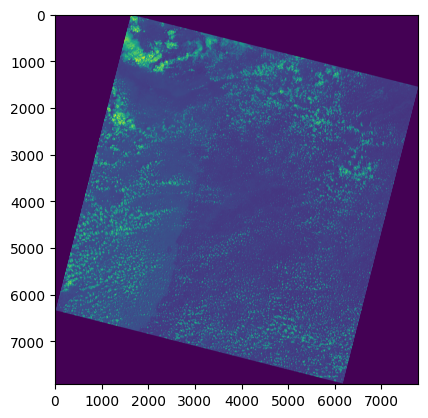

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 7791, 'height': 7921, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32643"]]'), 'transform': Affine(30.0, 0.0, 143985.0,
       0.0, -30.0, 3633015.0)}


In [8]:
import rasterio
from rasterio.plot import show

# Reading in the band
with rasterio.open(image_L1_filename) as src:
    tiff_image = src.read()

# Display the image
show(tiff_image)

# Access the metadata
metadata = src.meta
print(metadata)


Using `gdal` to read in the image and subsequently displaying with `matplotlib`:

In [2]:
%pip install rasterio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import rasterio

# Open TIFF file
with rasterio.open(image_L1_filename) as src:
    tiff_array = src.read(1)  # read first band
    
    # Print metadata
    print("Size:", src.width, "x", src.height)
    print("\nCRS:", src.crs)
    print("\nTransform:", src.transform)
    print("\nData type:", src.dtypes[0])

Size: 7791 x 7921

CRS: EPSG:32643

Transform: | 30.00, 0.00, 143985.00|
| 0.00,-30.00, 3633015.00|
| 0.00, 0.00, 1.00|

Data type: uint16


Convert to numpy array & check the data numbers (DNs):

In [10]:
import numpy as np
tiff_array = np.array(tiff_array)
print(tiff_array)
print(tiff_array.dtype)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
uint16


Check the data type:

In [11]:
print(tiff_array.dtype)

uint16


Level-1 data products consist of quantized and calibrated scaled Digital Numbers (DN) representing the multispectral image data.  Landsat 8 and Landsat 9 data are delivered in 16-bit unsigned integer format. Landsat 1-7 products are delivered in 8-bit unsigned integer format. Landsat Level-1 data can be converted to TOA spectral radiance, reflective band DN’s can be converted to TOA reflectance, and thermal band data can be converted from spectral radiance to TOA  brightness temperature.
[Read more here](https://www.usgs.gov/landsat-missions/using-usgs-landsat-level-1-data-product). 

## Computing Radiance

### Convert 16-bit DNs to Radiance

Landsat Level-1 data can be converted to TOA spectral radiance using the radiance rescaling factors in the MTL file:

where:

$$ L_{λ} = M_{L} Q_{cal } + A_{L}$$

- $L_{λ}$ = TOA spectral radiance [W/($m^2$ sr μm)]
- $M_{L}$ = Band-specific multiplicative rescaling factor from the metadata (`RADIANCE_MULT_BAND_x`, where x is the band number)
- $A_{L}$= Band-specific additive rescaling factor from the metadata (`RADIANCE_ADD_BAND_x`, where x is the band number)
- $Q_{cal }$ =  Quantized and calibrated standard product pixel values (`DN`)         

 

The scaling factors are available in the metadata file: `LC09_L1TP_150038_20240803_20240803_02_T1_MTL.txt`.

In [19]:
Landsat9_mtt_dict = {}

# Reading in the metadata
metadata_filename = os.path.join(dataDirectory, "LC09_L1TP_150038_20240803_20240803_02_T1_MTL.txt")
with open(metadata_filename, 'r') as _:
    for line in _:
        line = line.strip()
        if line != 'END':
            key, value = line.split('=')
            key = key.rstrip()
            Landsat9_mtt_dict[key] = value

key = None
value = None

In [20]:
# Read multiplicative rescaling factor for band 3 from the dictionary i.e. 'RADIANCE_MULT_BAND_3' & 'RADIANCE_ADD_BAND_3'
#---> Your code


Converting string variables to float values:

In [21]:
m_lambda = float(Landsat9_mtt_dict['RADIANCE_MULT_BAND_3'].strip().strip('"'))
a_lambda = float(Landsat9_mtt_dict['RADIANCE_ADD_BAND_3'].strip().strip('"')) 

Calculation for conversion of DNs to radiance:

In [22]:
radiance_b3 = m_lambda * tiff_array.astype(np.float32) + a_lambda 


Plotting the two rasters:

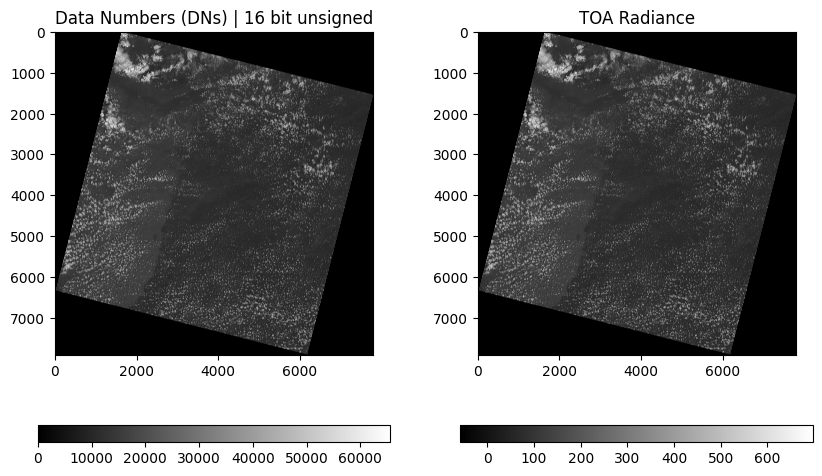

In [18]:
import matplotlib.pyplot as plt

plt.figure('GMT vs TIFF', figsize=(10, 6))
plt.subplot(1,2,1)
im1 = plt.imshow(tiff_array, cmap='gray')
ax1 = im1.axes
ax1.set_title('Data Numbers (DNs) | 16 bit unsigned')
plt.colorbar(im1, orientation='horizontal')

plt.subplot(1,2,2)
im2 = plt.imshow(radiance_b3, cmap='gray')
ax2 = im2.axes
ax2.set_title('TOA Radiance')
plt.colorbar(im2, orientation='horizontal')
plt.show()

<div class="alert alert-dark">
<font size="5"> <b> Questions <b> </font>
</div>

:question: Look at the scale on the colorbar and note the different in the range of data values for both rasters. Comment

Type your answer here.

:question: Why is the colorbar for radiance image extending to negative values? Please comment, and if it is a problem, suggest a way to correct it.


Type your answer here.

## Let's use rioxarray for reading in and displaying image

Installing the libraries `rioaxrray` & `rasterio`

In [23]:
!pip install rioxarray #rasterio

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#rasterio': Expected package name at the start of dependency specifier
    #rasterio
    ^


Reading in the image, and printing out some relevant information:

In [24]:
import rioxarray
image_L1 = rioxarray.open_rasterio(image_L1_filename)
image_L1.head()

<xarray.DataArray (band: 1, y: 5, x: 5)> Size: 50B
[25 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 40B 3.633e+06 3.633e+06 ... 3.633e+06 3.633e+06
  * x            (x) float64 40B 1.44e+05 1.44e+05 1.441e+05 1.441e+05 1.441e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0

:question: What is the no data value?

In [25]:
# Access the no data value
no_data_value = image_L1.rio.nodata
print(f"Current no data value: {no_data_value}")

Current no data value: 0


Let's prepare a mask of the no data values, so that we can remove it later on.

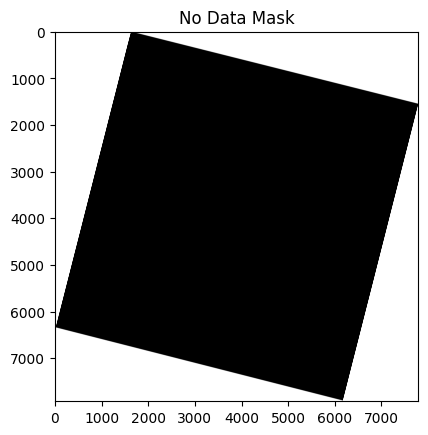

In [26]:
import matplotlib.pyplot as plt
# Create a mask of no data values
no_data_mask = image_L1 == no_data_value

# Plot the no data mask
plt.imshow(no_data_mask[0], cmap='gray')  # Use the first band if the image has multiple bands
plt.title('No Data Mask')
plt.show()

Plotting image after masking out the no data values:

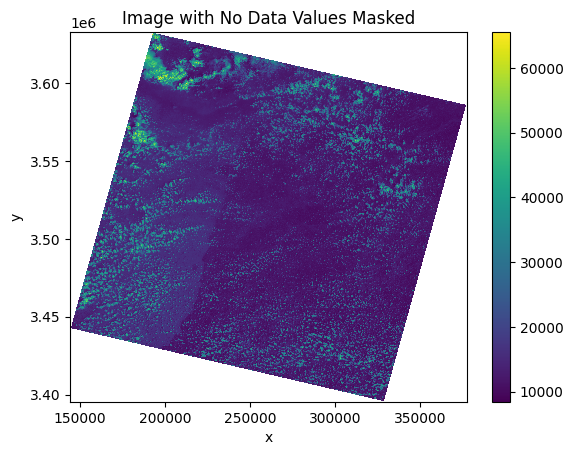

In [27]:
masked_image = image_L1.where(~no_data_mask)
image_L1 = None # not required subsequently

# Plot the masked image
masked_image.plot()
plt.title('Image with No Data Values Masked')
plt.show()

:question: What are `x` and `y` labels, and what do these numbers of the x and y axes represent?

Getting information of the coordinate reference system:

In [28]:
print(masked_image.rio.crs)

EPSG:32643


Read more about EPSG:32643 [here](https://epsg.io/32643).
> You can self study, Coordinate reference sytsems (CRS), e.g. on [Wikipedia](https://en.wikipedia.org/wiki/Spatial_reference_system). At the least, know that a coordinate reference system pinpoints the 3-D geolocation of any point.

Let us covert the CRS to EPSG:4326 WGS84 (lat/long), which is the more commonly known CRS.

In [32]:
# Reproject the image to EPSG:4326
image_L1_reprojected = masked_image.rio.reproject("EPSG:4326") 

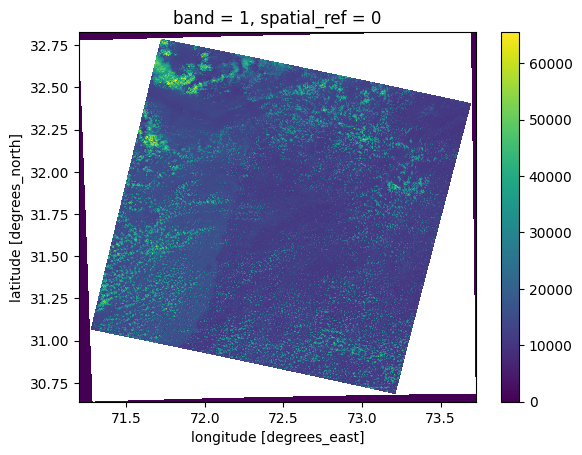

In [30]:
image_L1_reprojected.plot()

:question: What do you see the artificats on the border?

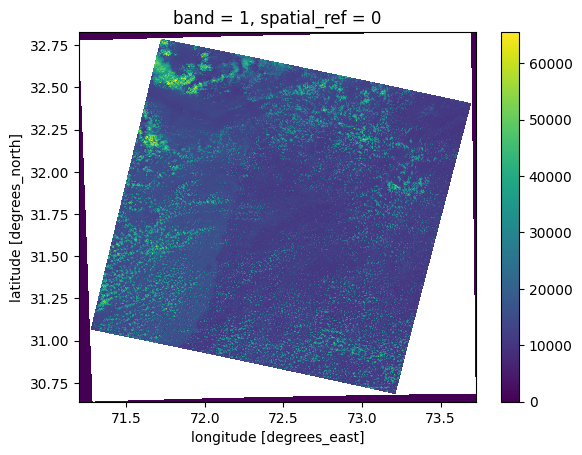

In [33]:
import numpy as np
image_L1_reprojected = image_L1_reprojected.astype(np.float32)
image_L1_reprojected.plot()
masked_image = None

Compute the radiance by using the reprojected image

In [35]:
radiance_b3 = m_lambda * image_L1_reprojected.astype(np.float32) + a_lambda
radiance_b3.head()

<xarray.DataArray (band: 1, y: 5, x: 5)> Size: 100B
array([[[-57.58461, -57.58461, -57.58461, -57.58461, -57.58461],
        [-57.58461, -57.58461, -57.58461, -57.58461, -57.58461],
        [-57.58461, -57.58461, -57.58461, -57.58461, -57.58461],
        [-57.58461, -57.58461, -57.58461, -57.58461, -57.58461],
        [-57.58461, -57.58461, -57.58461, -57.58461, -57.58461]]],
      dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 40B 32.83 32.83 32.83 32.83 32.83
  * x            (x) float64 40B 71.2 71.2 71.2 71.2 71.2
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Point
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0.0

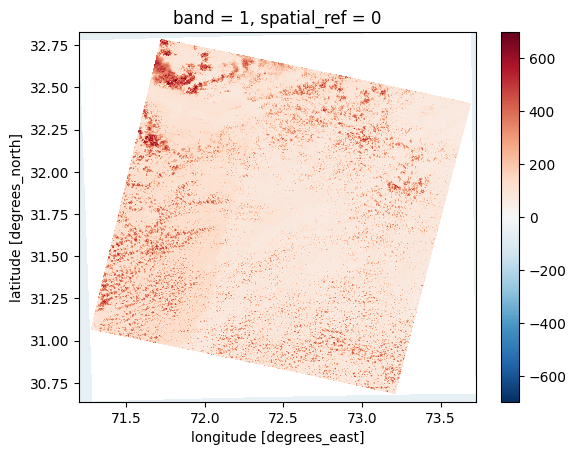

In [37]:
radiance_b3.sel(band = 1).plot()